# Домашняя работа №6 — кластеризация

**Данные:** ~2240 клиентов розничной сети — возраст, доход, траты по категориям, каналы покупок.

**Задача:** разбить клиентов на группы, чтобы каждую можно было назвать одним словом — «экономные», «премиум», «семейные».

Код в модулях (`modules/`). `main.py` прогоняет всё и сохраняет графики в `output/`. Здесь — по шагам вручную с отображением графиков в ноутбуке.


## 1. Импорт и загрузка

Если `data/marketing_campaign.csv` нет — скачается сам.

In [1]:
%matplotlib inline

from pathlib import Path

from modules import (
    ClusterBench,
    ClusterEvaluator,
    ClusterVisualizer,
    CustomerDataset,
    CustomerPreprocessor,
    HypothesisTester,
)
from modules.preprocessing import SPENDING_COLS

ROOT = Path('.').resolve()
DATA = ROOT / 'data'
OUT = ROOT / 'output'
K_PREFERRED = 4
RANDOM_STATE = 42

dataset = CustomerDataset(DATA)
preprocessor = CustomerPreprocessor()
evaluator = ClusterEvaluator(random_state=RANDOM_STATE)
bench = ClusterBench(random_state=RANDOM_STATE)
viz = ClusterVisualizer(OUT)
hyp_tester = HypothesisTester()

raw = dataset.load()
raw.head()


[CustomerDataset] rows=2240, cols=29, Income mean=52247, пропусков Income=24


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## 2. EDA — распределения, выбросы, корреляции

In [2]:
eda = preprocessor.describe_eda(raw)
print('Пропуски:', dict(eda['missing']))
print('Константные:', eda['const_cols'])
print('\nТоп по range:')
eda['scale'].head(8)


Пропуски: {'Income': np.int64(24)}
Константные: ['Z_CostContact', 'Z_Revenue']

Топ по range:


,min,max,mean,std,range
Income,1730.0,666666.0,52247.251354,25173.076661,664936.0
MntMeatProducts,0.0,1725.0,166.950000,225.715373,1725.0
MntWines,0.0,1493.0,303.935714,336.597393,1493.0
MntGoldProds,0.0,362.0,44.021875,52.167439,362.0
MntSweetProducts,0.0,263.0,27.062946,41.280498,263.0
MntFishProducts,0.0,259.0,37.525446,54.628979,259.0
MntFruits,0.0,199.0,26.302232,39.773434,199.0
Year_Birth,1893.0,1996.0,1968.805804,11.984069,103.0


[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\eda_distributions.png


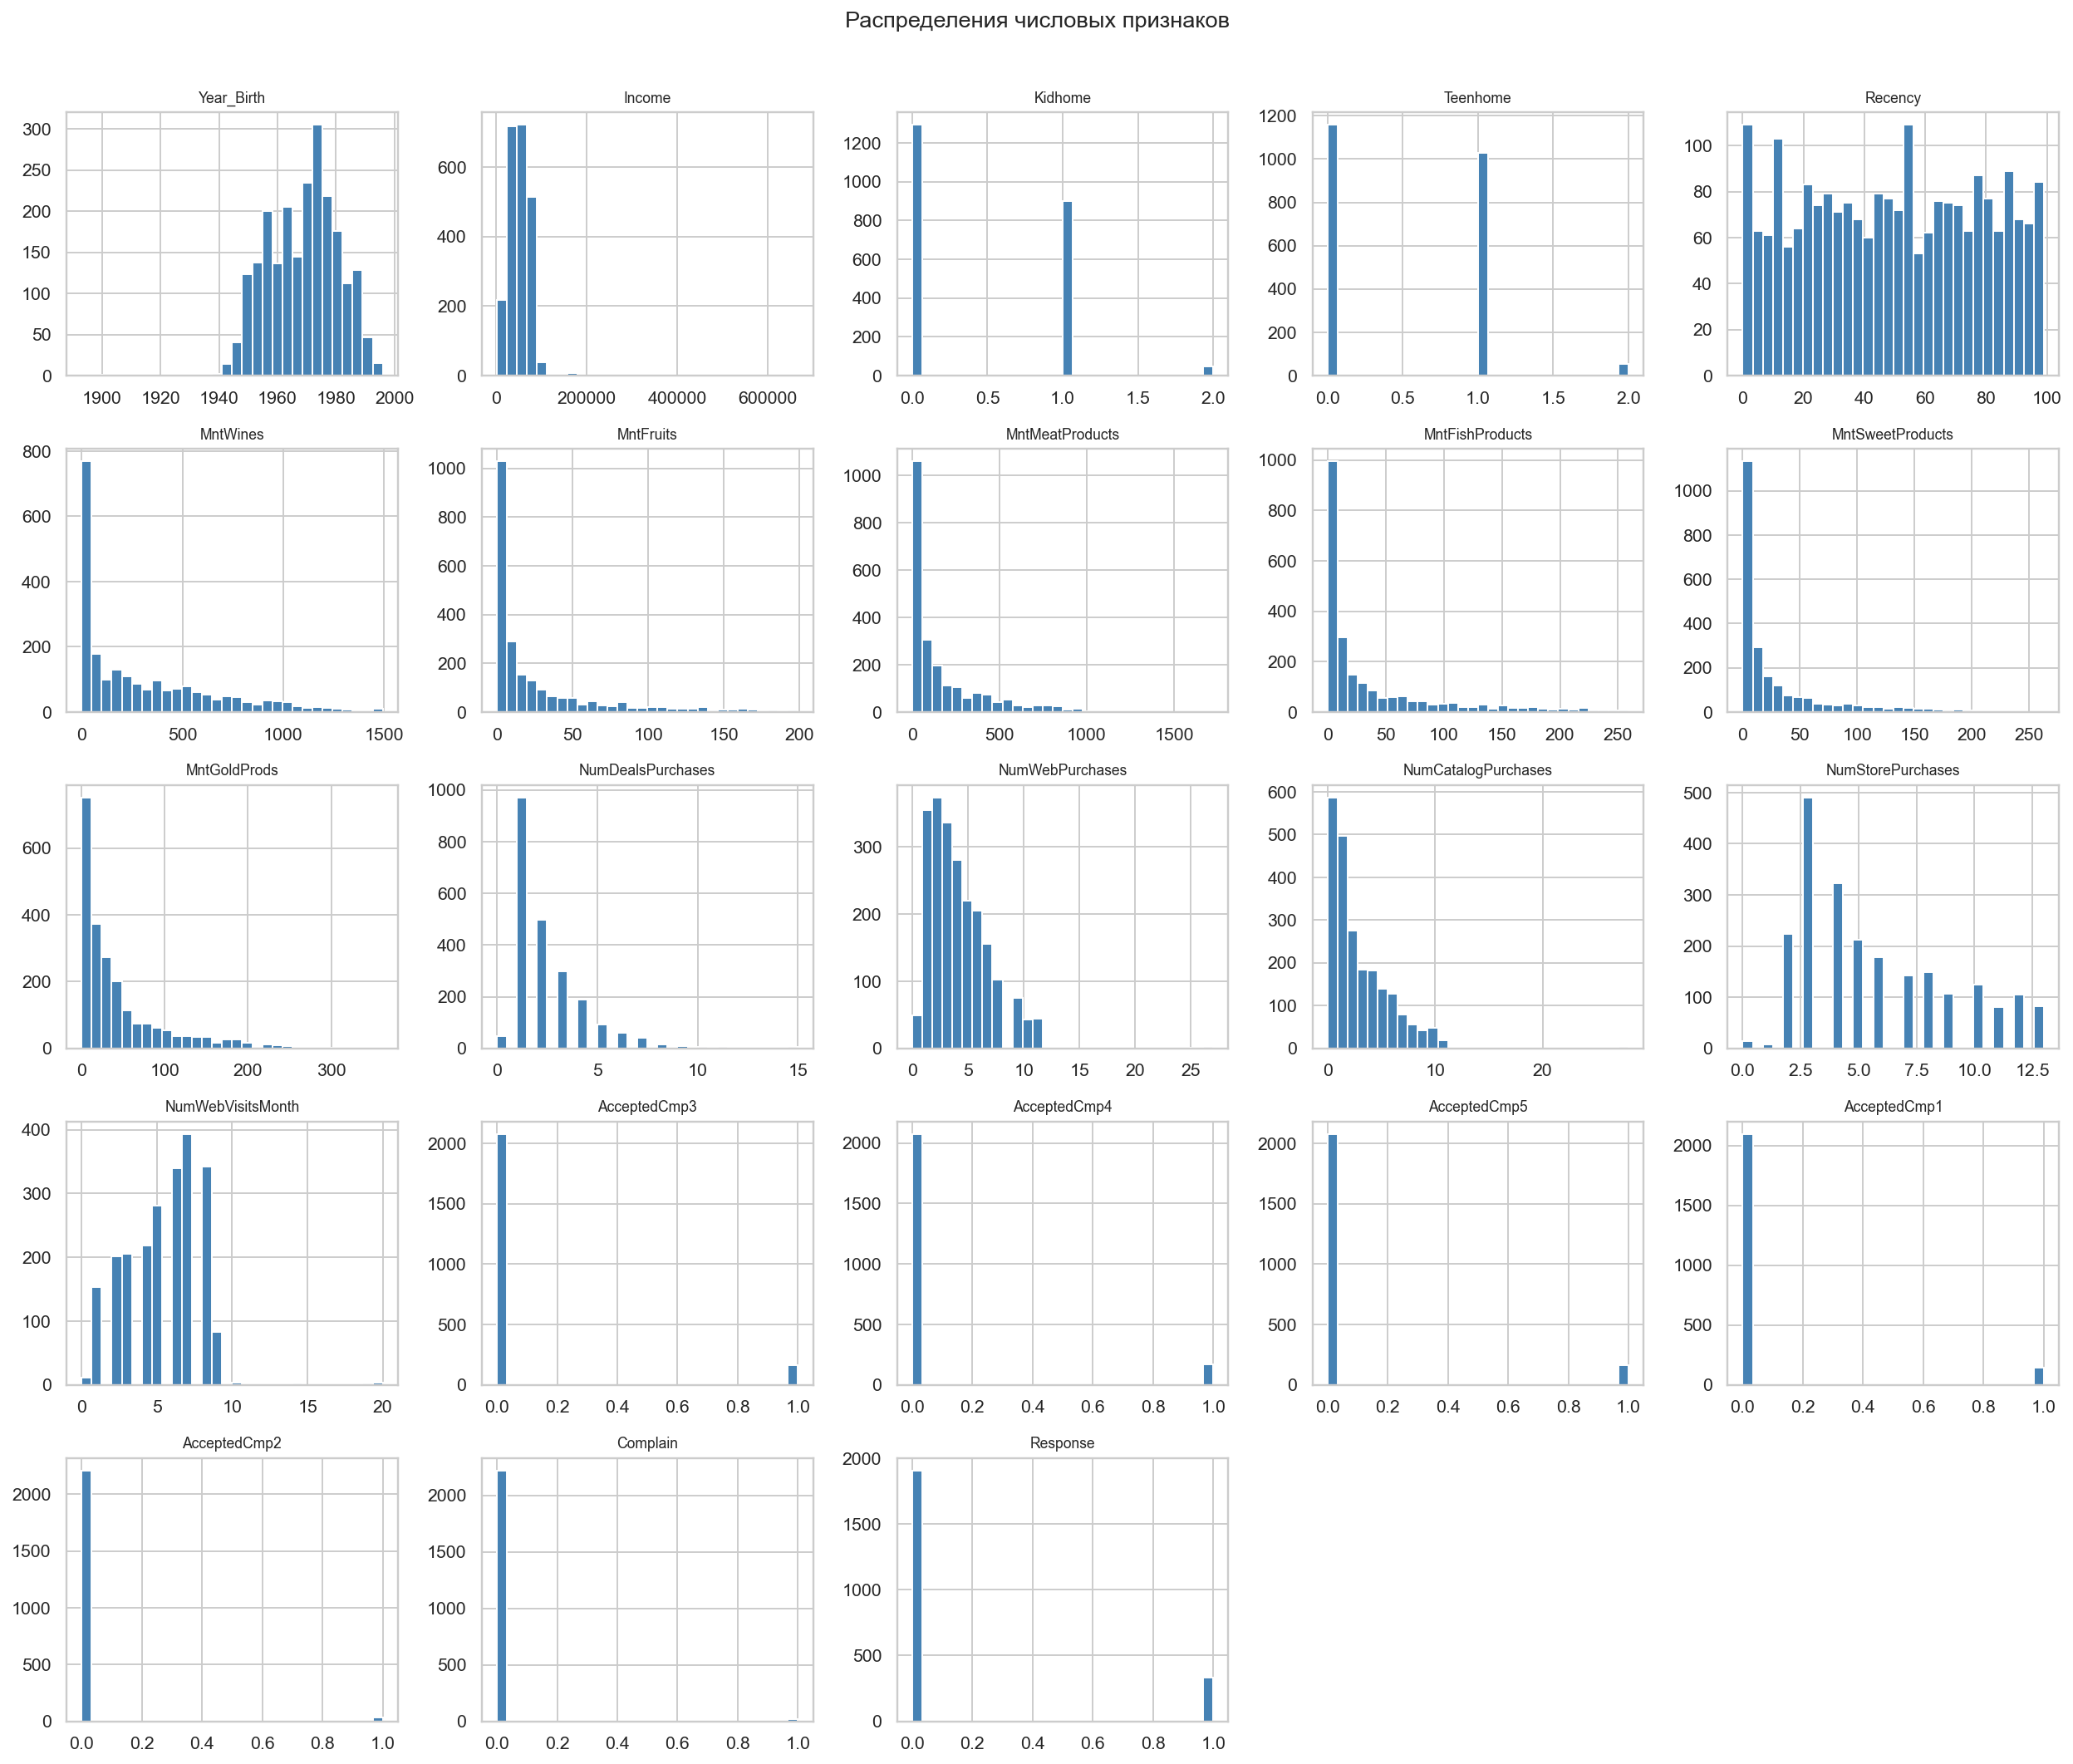

[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\eda_spending_boxplots.png


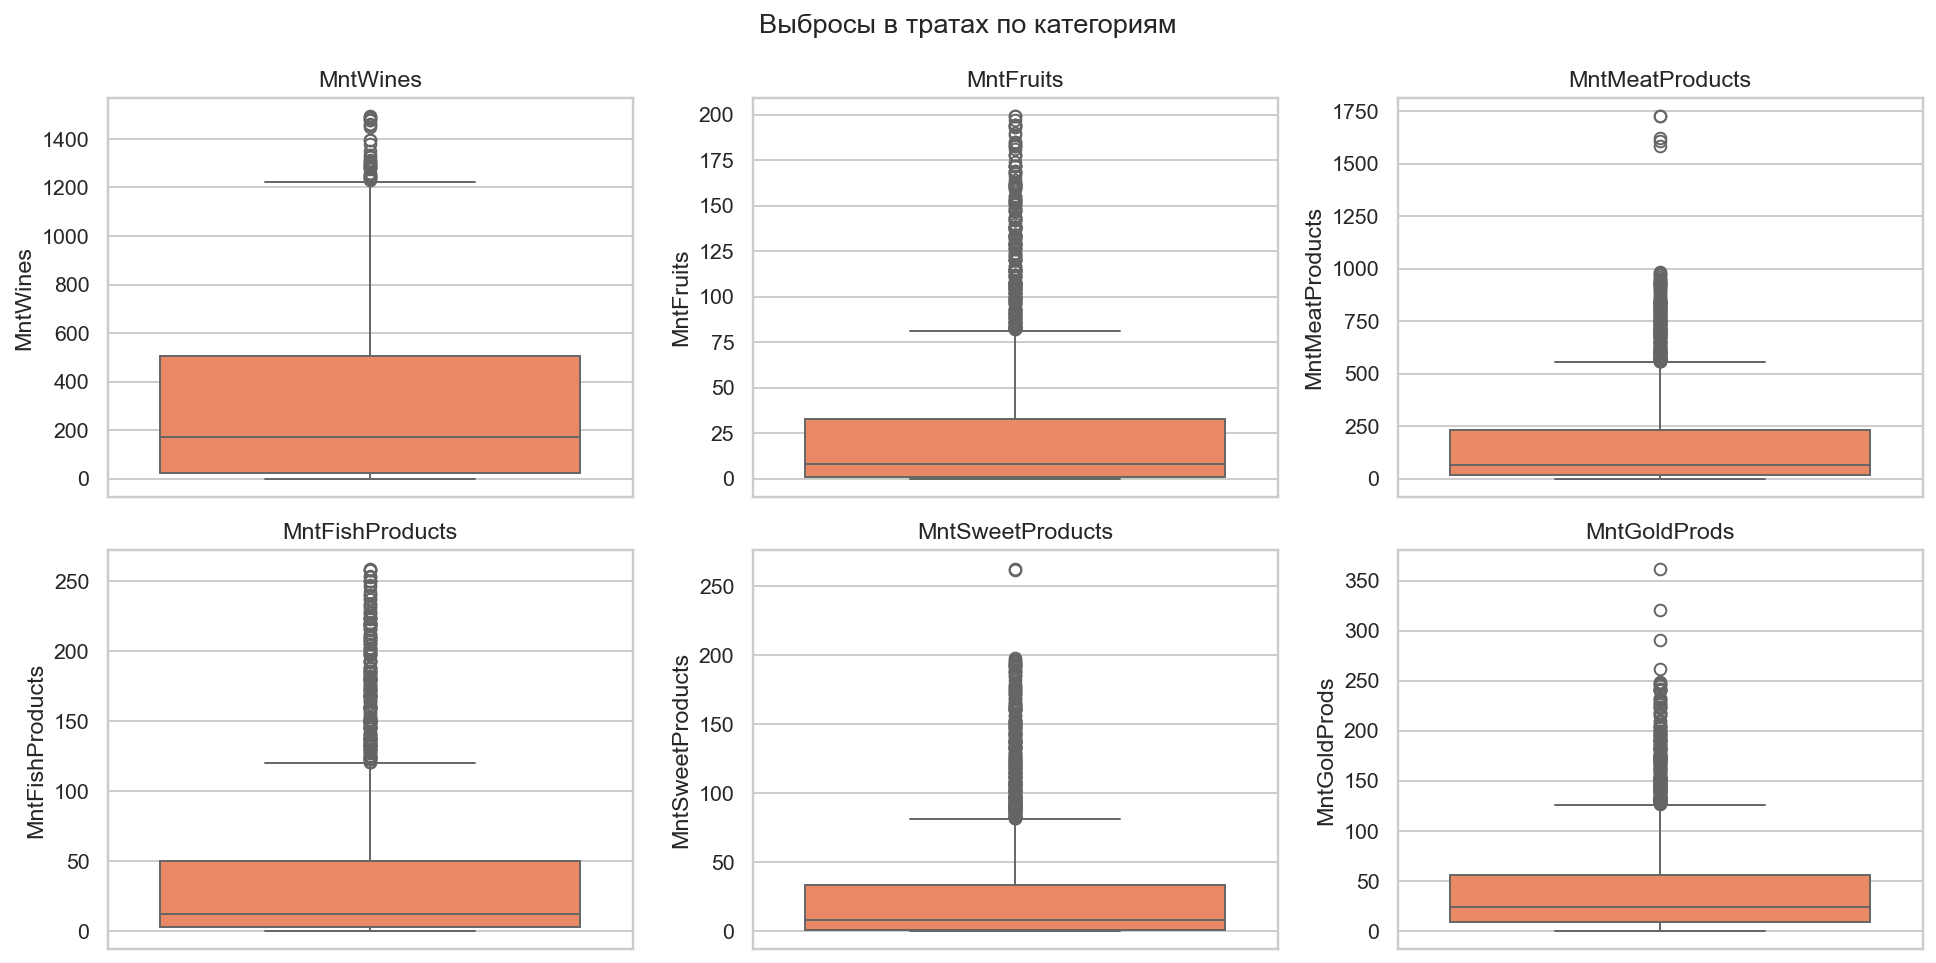

[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\eda_correlation.png


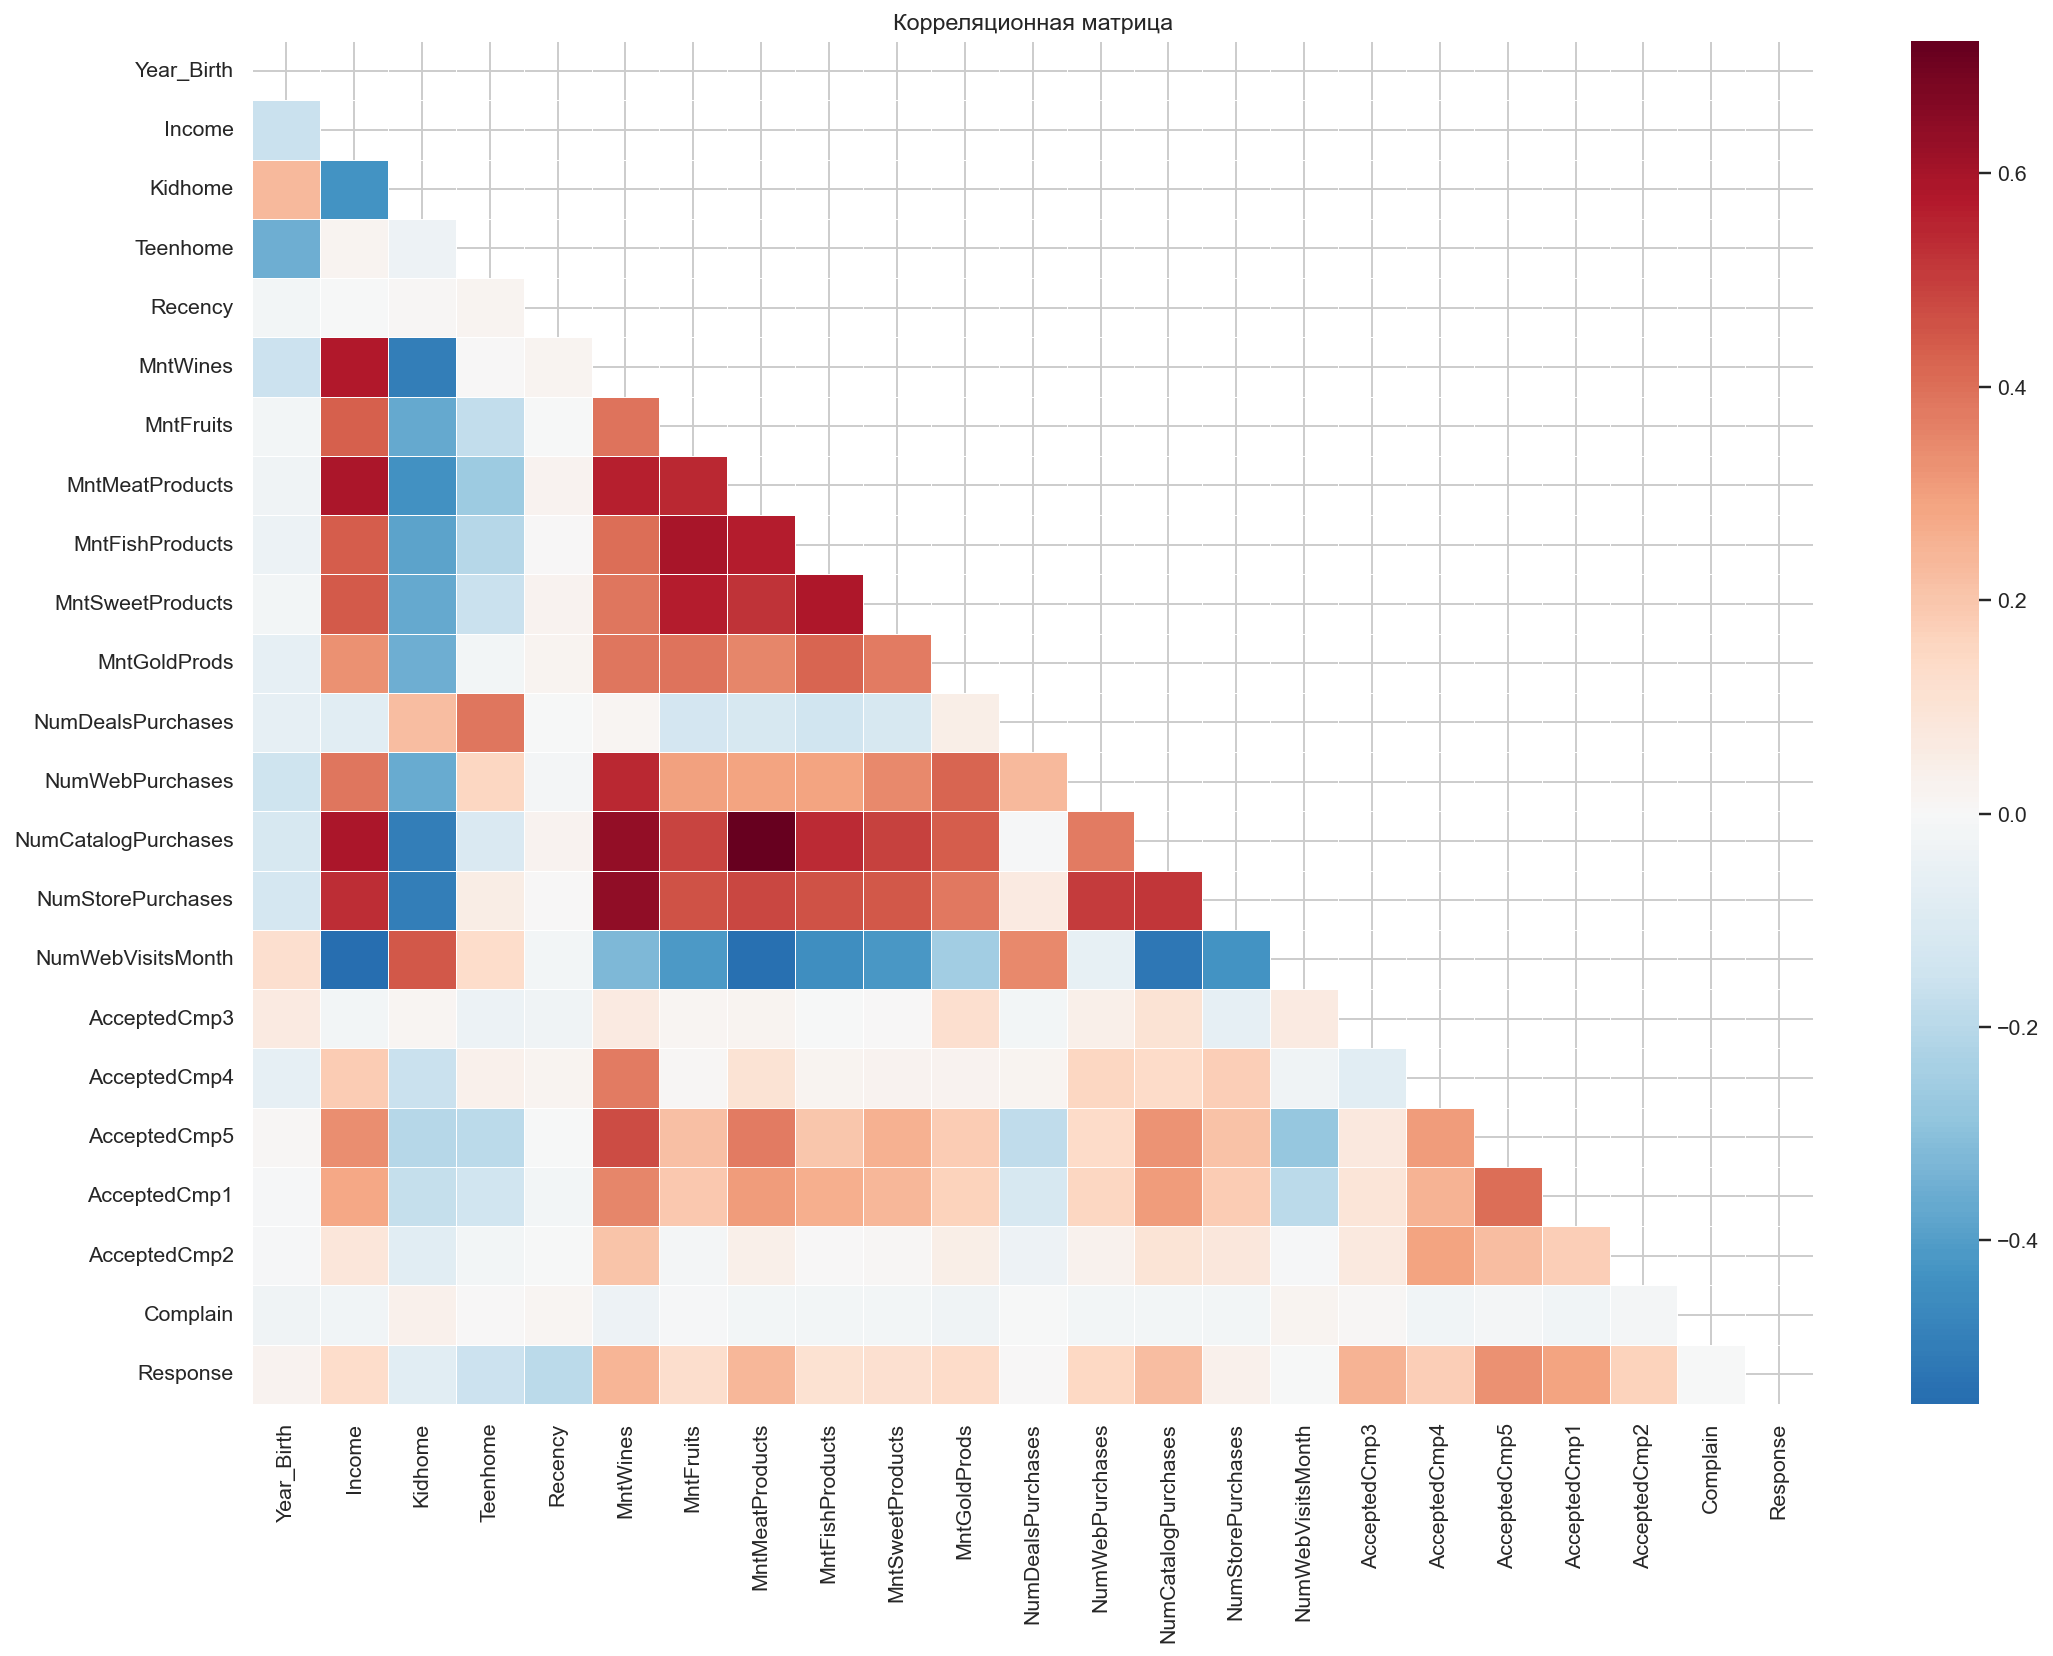

WindowsPath('C:/Users/Dezhurny/Desktop/Lesson6/output/eda_correlation.png')

In [3]:
viz.plot_numeric_distributions(raw, list(eda['num_cols']))
viz.plot_spending_boxplots(raw, SPENDING_COLS)
viz.plot_correlation_heatmap(raw, list(eda['num_cols']))


## 3–6. Предобработка

- **Выбросы:** IQR-winsorization (не удаляем строки — K-Means чувствителен)
- **Мультиколлинеарность:** убираем признаки с |r|>0.8 к агрегатам
- **Family_Size:** Kidhome + Teenhome + Adults (2 при Married/Together, иначе 1)
- **Масштабирование:** RobustScaler (не усиливает выбросы как StandardScaler)


In [4]:
prepared = preprocessor.prepare(raw)
print(f'Признаков: {len(prepared.feature_names)}')
print(f'Скейлер: {prepared.scaler_name}')
print(f'Удалено (мультиколлинеарность): {list(prepared.dropped_cols)}')
print(f'Обрезано выбросов (IQR): {sum(prepared.outlier_stats.values())}')
prepared.processed[['Age', 'Income', 'Family_Size', 'Adults_In_Household', 'Total_Spending']].head()


[Preprocessor] признаков=36, строк=2240, RobustScaler, outliers_capped=1131, dropped_multicollinear=['MntMeatProducts', 'NumStorePurchases', 'NumWebPurchases']
Признаков: 36
Скейлер: RobustScaler
Удалено (мультиколлинеарность): ['MntMeatProducts', 'NumStorePurchases', 'NumWebPurchases']
Обрезано выбросов (IQR): 1131


,Age,Income,Family_Size,Adults_In_Household,Total_Spending
0,67,58138.0,1,1,1617
1,70,46344.0,3,1,27
2,59,71613.0,2,2,776
3,40,26646.0,3,2,53
4,43,58293.0,3,2,422


## Влияние выбросов на K-Means

Сравнение silhouette: IQR-cap + RobustScaler vs без обработки + StandardScaler.

[Preprocessor] признаков=36, строк=2240, StandardScaler, outliers_capped=0, dropped_multicollinear=['MntMeatProducts', 'NumStorePurchases', 'NumWebPurchases']


[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\outlier_impact_silhouette.png


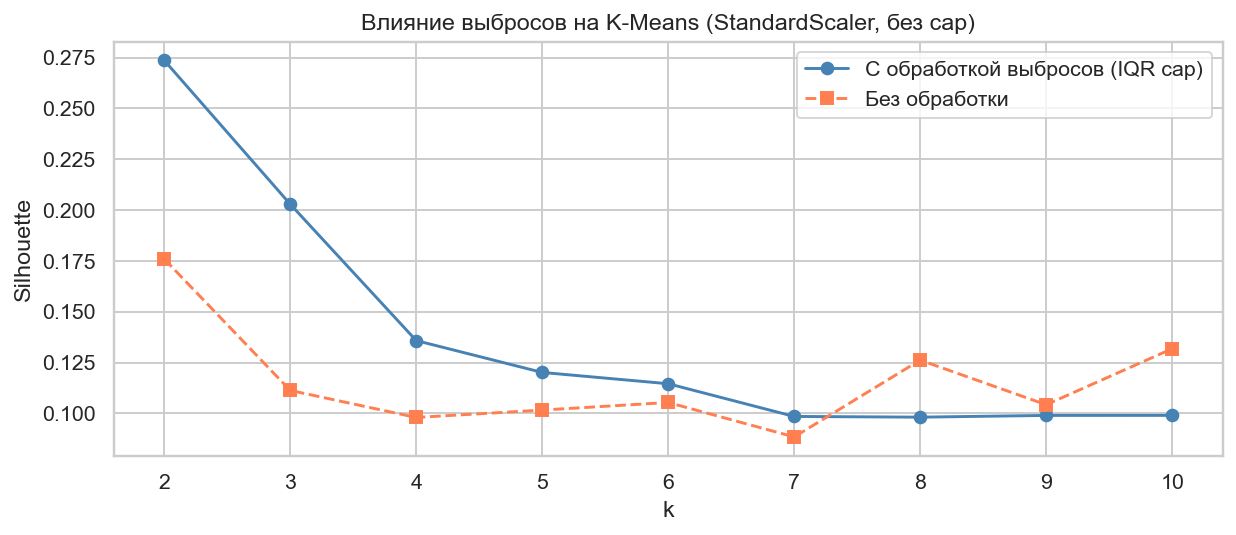

WindowsPath('C:/Users/Dezhurny/Desktop/Lesson6/output/outlier_impact_silhouette.png')

In [5]:
prepared_raw = preprocessor.prepare(
    raw, handle_outliers=False, drop_multicollinear=True, scaler='standard'
)
k_search_robust = evaluator.search_k(prepared.x, k_min=2, k_max=10)
k_search_raw = evaluator.search_k(prepared_raw.x, k_min=2, k_max=10)
viz.plot_outlier_impact(
    k_search_robust.k_range,
    k_search_robust.silhouettes,
    k_search_raw.silhouettes,
)


## Гипотезы и проверки (H1–H6)

| ID | Гипотеза |
|----|----------|
| H1 | Чем выше доход, тем реже покупают по скидкам |
| H2 | Доход влияет на предпочтение веб-канала |
| H3 | Семьи с детьми тратят больше на мясо |
| H4 | Возраст связан с давностью покупки (Recency) |
| H5 | Образование влияет на траты на вино |
| H6 | Верхний квартиль дохода реже использует скидки |


In [6]:
hyp_results = hyp_tester.run_all(prepared.processed)
hyp_table = hyp_tester.summary_table(hyp_results)
hyp_table[['id', 'hypothesis', 'test', 'p_value', 'significant', 'conclusion']]


,id,hypothesis,test,p_value,significant,conclusion
0,H1,"Чем выше доход, тем реже покупают по скидкам (...",Pearson r,0.000000,True,"Подтверждена: отрицательная связь (r=-0.115, p..."
1,H2,Доход влияет на предпочтение веб-канала (NumWe...,Kruskal-Wallis,0.000000,True,"Подтверждена: Q1 веб=2.0, Q4 веб=5.3 (p=0.0000)"
2,H3,Семьи с детьми тратят больше на мясо (MntMeatP...,Mann-Whitney U,1.000000,False,Не подтверждена (p=1.0000)
3,H4,Возраст связан с давностью последней покупки (...,Spearman ρ,0.328366,False,"Слабая/нет связи (ρ=0.021, p=0.3284)"
4,H5,Уровень образования влияет на траты на вино (M...,Kruskal-Wallis,0.000000,True,Подтверждена: макс. MntWines у PhD (p=0.0000)
5,H6,Верхний квартиль дохода реже покупает по скидк...,Mann-Whitney U,0.000000,True,"Подтверждена: high=1.4 deals, low=2.1 deals (p..."


[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\hypothesis_income_deals.png


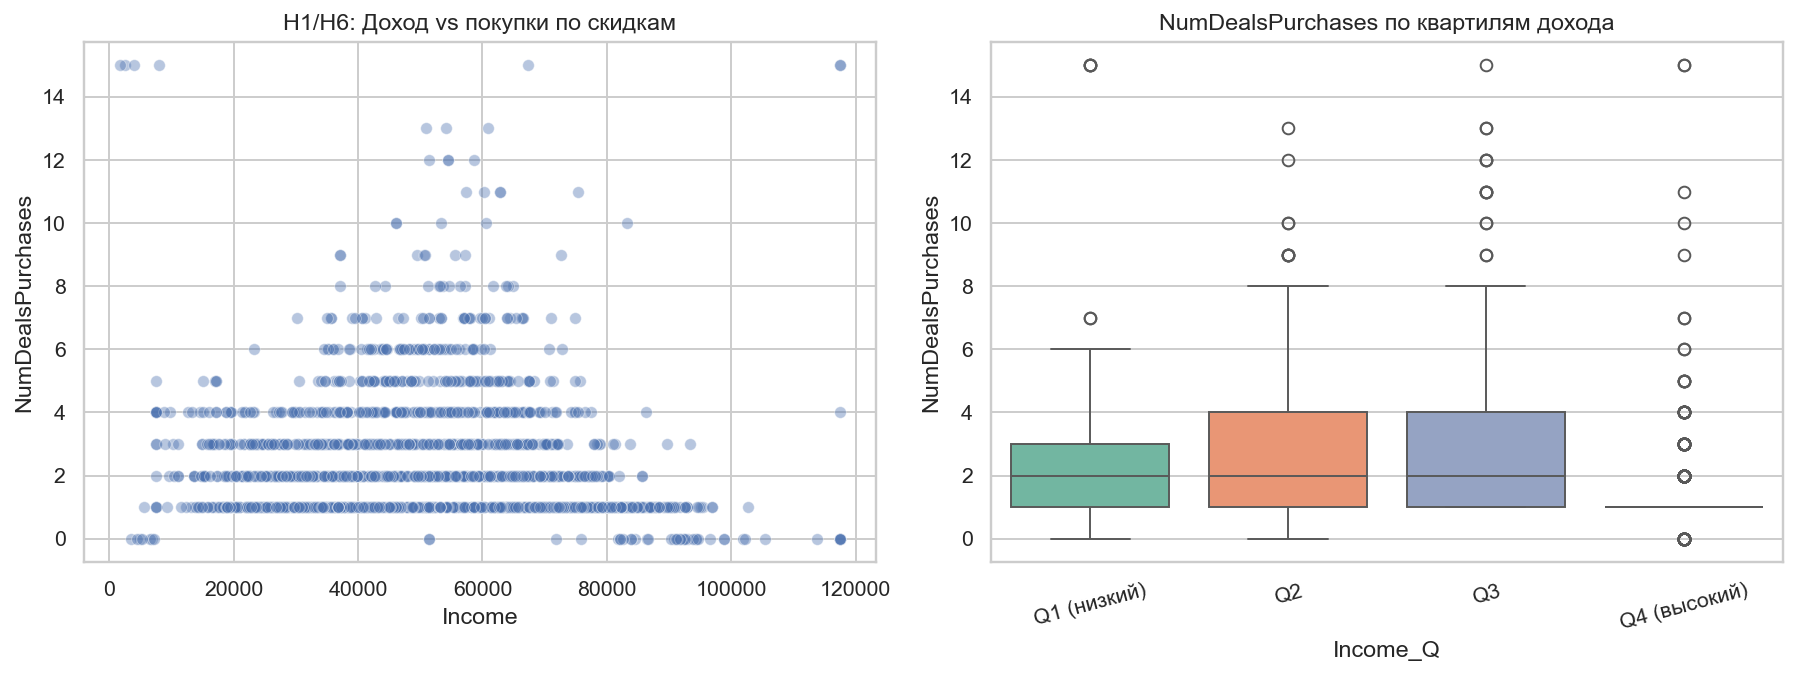

[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\hypothesis_income_channels.png


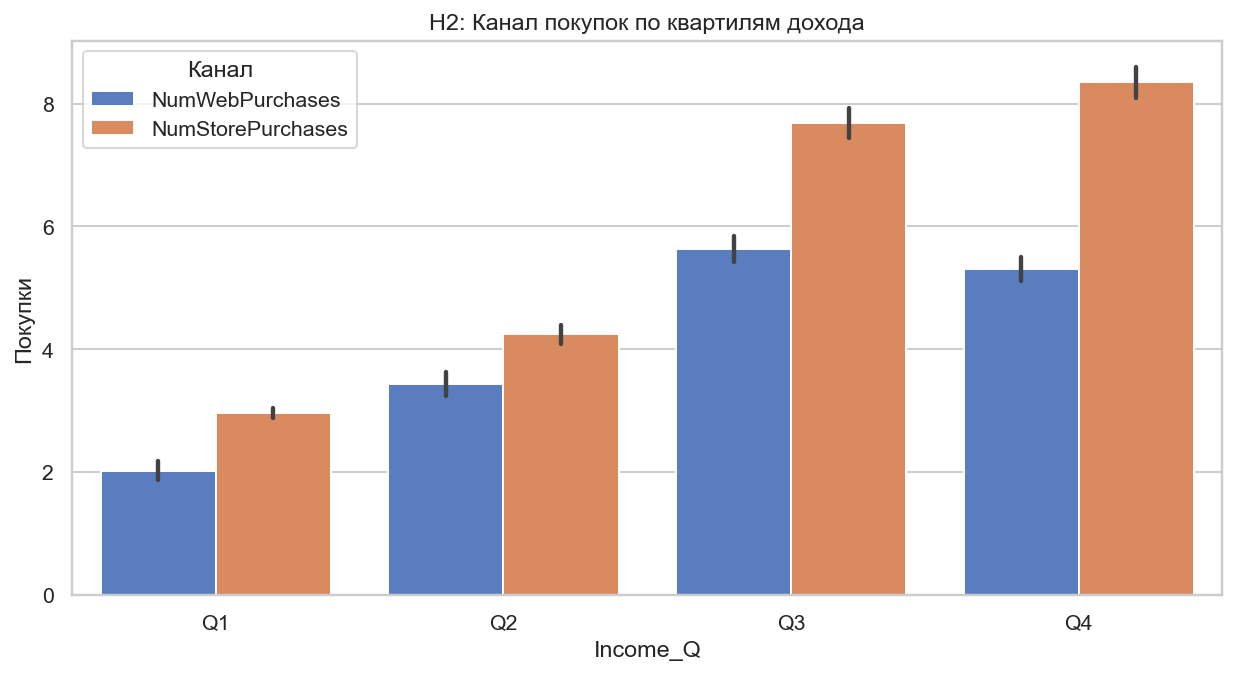

[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\hypothesis_family_meat.png


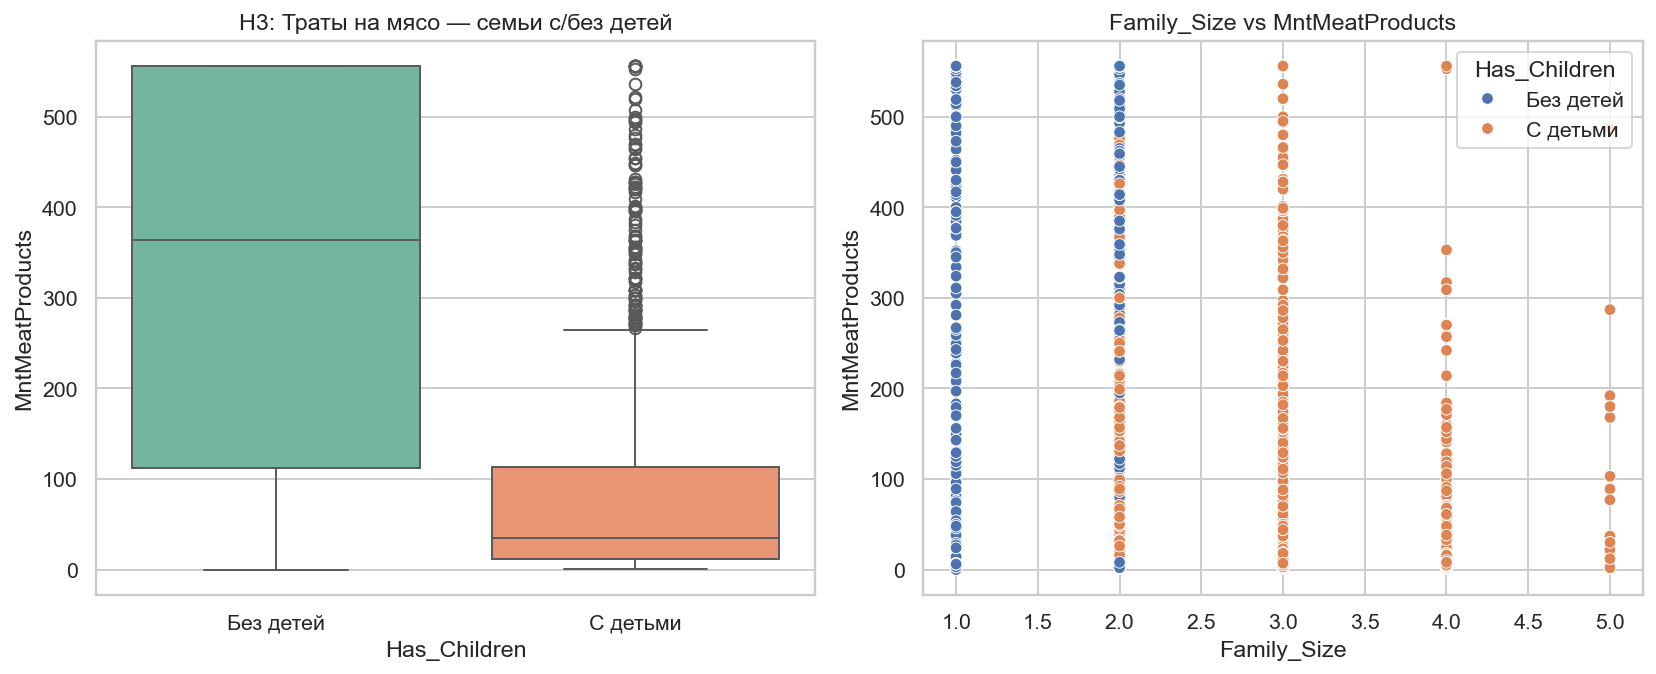

WindowsPath('C:/Users/Dezhurny/Desktop/Lesson6/output/hypothesis_family_meat.png')

In [7]:
viz.plot_hypothesis_income_deals(prepared.processed)
viz.plot_hypothesis_channels(prepared.processed)
viz.plot_hypothesis_family_meat(prepared.processed)


## 8. Выбор числа кластеров (Elbow + Silhouette)

`pick_k`: preferred k, если silhouette ≥ 90% от максимума; иначе — best_sil.

[Evaluator] k=2: silhouette=0.274 — preferred k=4 дал бы 0.136 (< 90%×max)
k=2: silhouette=0.274 — preferred k=4 дал бы 0.136 (< 90%×max)


[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\k_selection.png


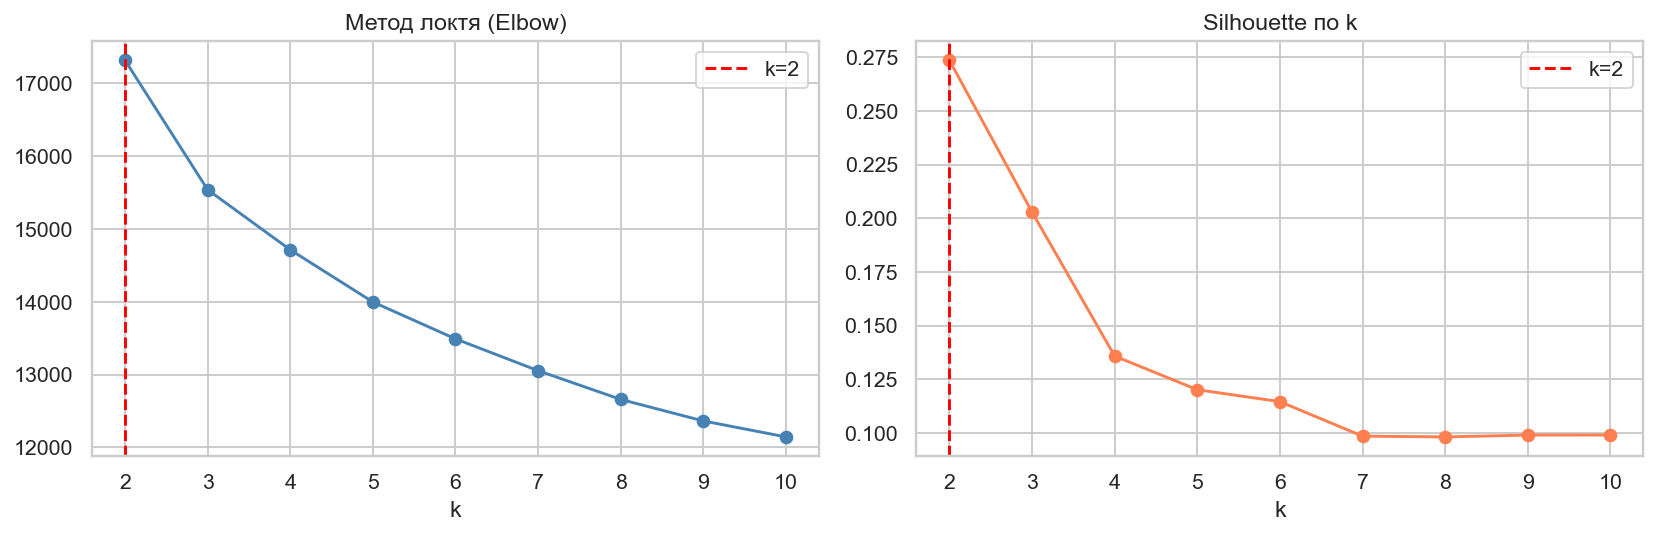

WindowsPath('C:/Users/Dezhurny/Desktop/Lesson6/output/k_selection.png')

In [8]:
k_pick = evaluator.pick_k(k_search_robust, preferred=K_PREFERRED, silhouette_threshold=0.90)
k_best = k_pick.k
print(k_pick.reason)
viz.plot_k_search(
    k_search_robust.k_range,
    k_search_robust.inertias,
    k_search_robust.silhouettes,
    k_best=k_best,
)


## 7. Кластеризация: K-Means → Spectral

In [9]:
results = bench.run_all(prepared.x, k=k_best)
summary = bench.summary_table()
summary


,method,silhouette,n_clusters,n_noise
0,K-Means,0.273603,2,0
1,Agglomerative,0.263559,2,0
2,DBSCAN,NaN,1,55
3,HDBSCAN,0.148225,3,1046
4,GMM,0.235381,2,0
5,Spectral,0.126539,2,0


GMM: признаков=36, параметров≈1405
params/sample=0.6272, BIC=-29772, AIC=-37801
DBSCAN eps=2.825 (авто, k-distance graph)


[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\dbscan_k_distance.png


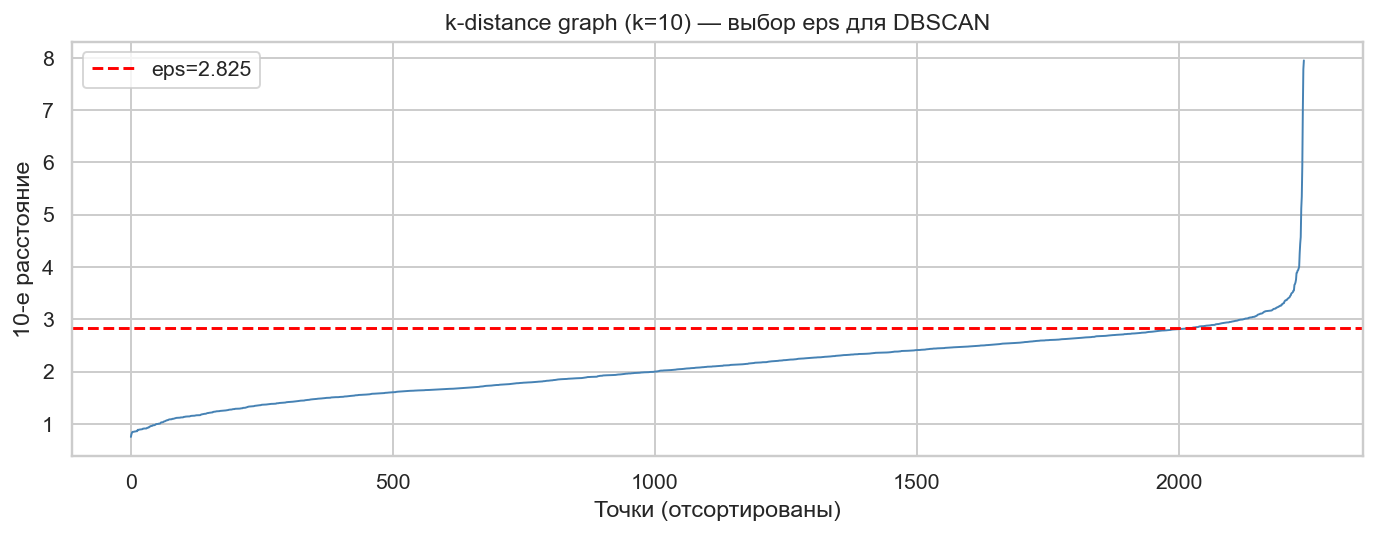

[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\hierarchical_dendrogram.png


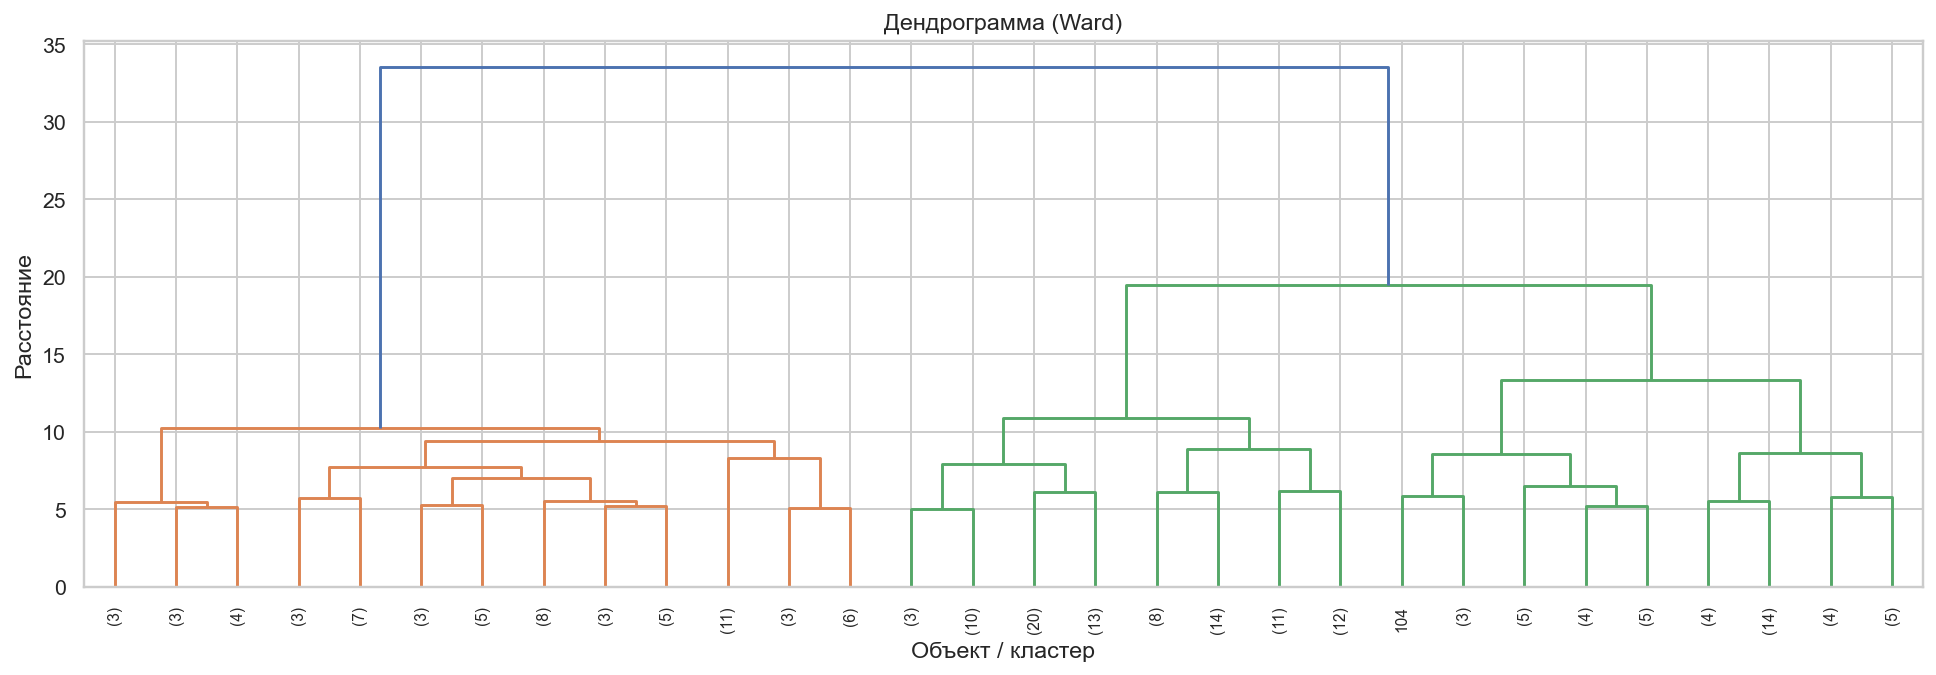

[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\methods_silhouette.png


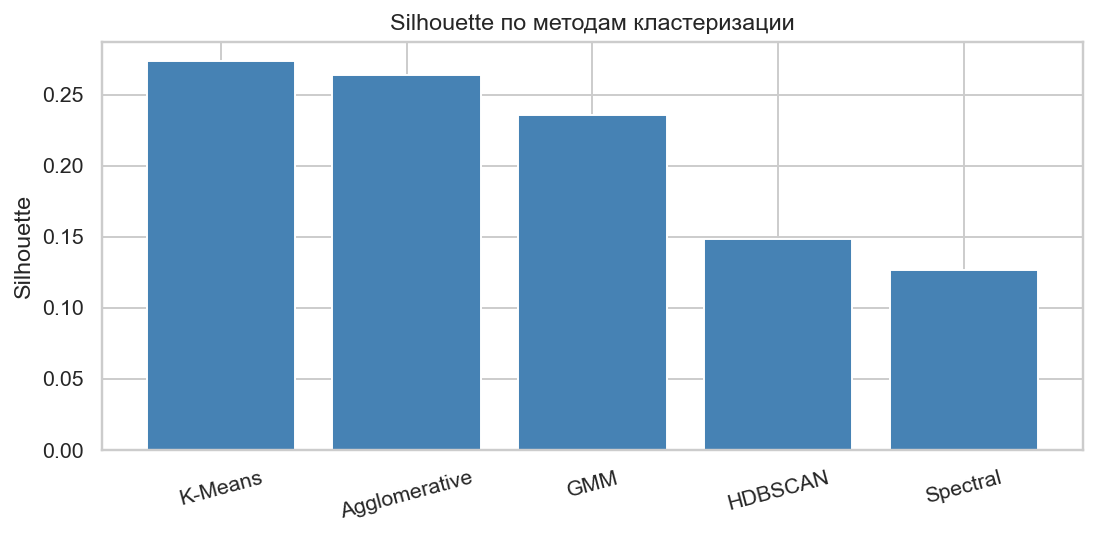

WindowsPath('C:/Users/Dezhurny/Desktop/Lesson6/output/methods_silhouette.png')

In [10]:
gmm = results['GMM'].extra
print(f"GMM: признаков={gmm['n_features']}, параметров≈{gmm['n_params']}")
print(f"params/sample={gmm['params_per_sample']}, BIC={gmm['bic']:.0f}, AIC={gmm['aic']:.0f}")
print(f"DBSCAN eps={results['DBSCAN'].extra.get('eps', '—'):.3f} (авто, k-distance graph)")

viz.plot_k_distance(prepared.x, min_samples=10, eps=results['DBSCAN'].extra.get('eps'))
viz.plot_dendrogram(prepared.x, random_state=RANDOM_STATE)
viz.plot_methods_comparison(summary)


In [11]:
labels = results['K-Means'].labels
profile = evaluator.cluster_profile(prepared.processed, labels, prepared.profile_cols)
profile


,Age,Income,Total_Spending,Total_Purchases,Recency,Family_Size,NumWebVisitsMonth,size
Cluster,,,,,,,,
0,56.5,71585.6,1248.5,21.5,49.5,2.1,3.6,842
1,54.4,39988.9,218.7,10.9,48.9,2.9,6.3,1398


## 9. Аномалии

In [12]:
anomalies = evaluator.detect_anomalies(
    prepared.x, labels,
    results['DBSCAN'].labels,
    results['HDBSCAN'].labels,
)
anomalies.counts


{'low_silhouette': 112,
 'dbscan_noise': 55,
 'hdbscan_noise': 1046,
 'isolation_forest': 112,
 'lof': 112,
 'all_5_methods': 2}

[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\anomalies_pca.png


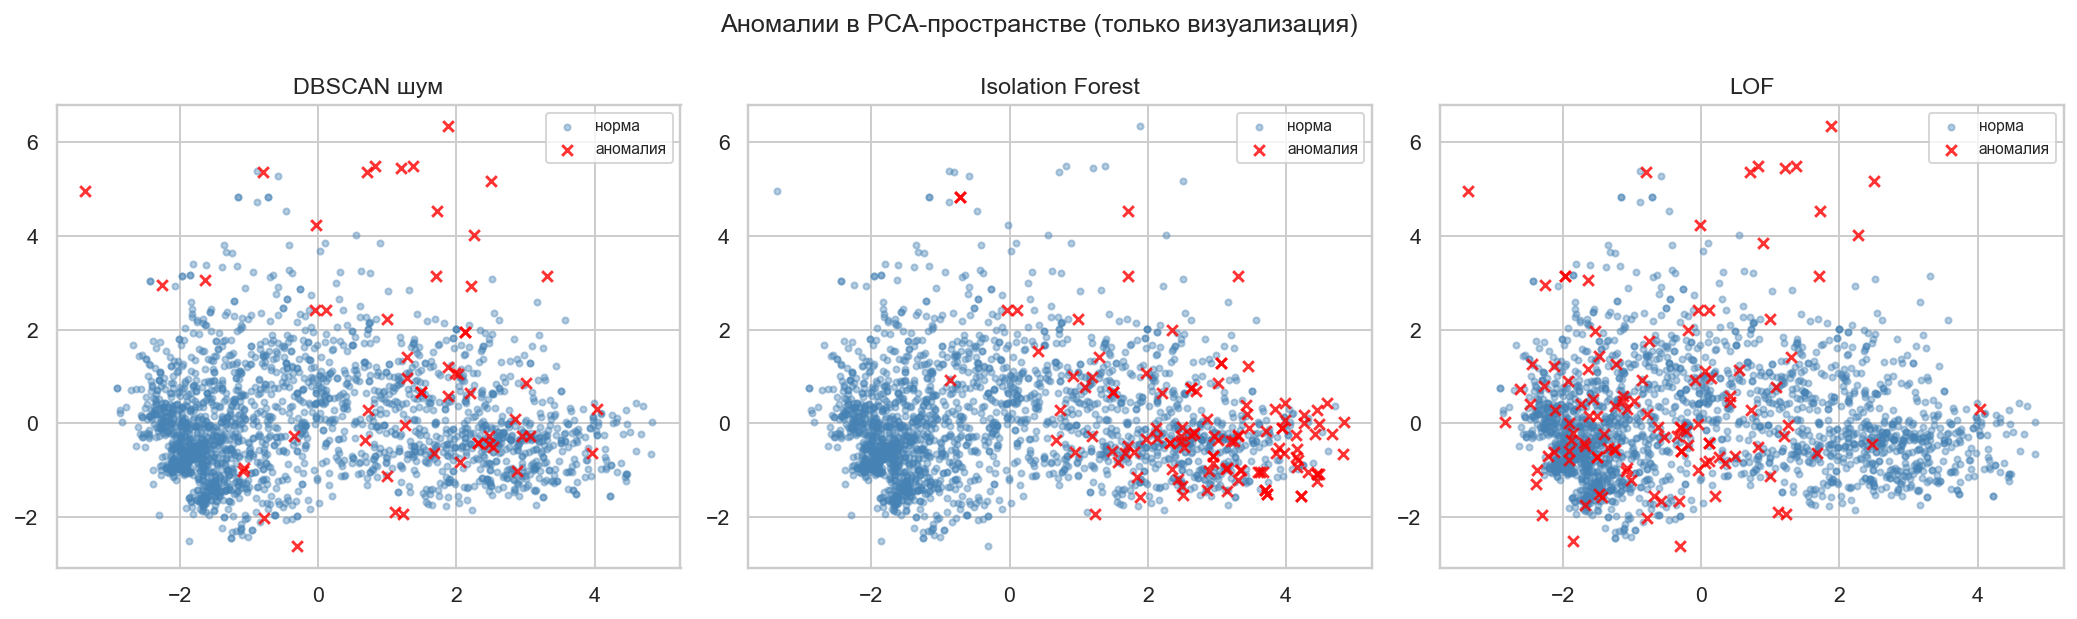

WindowsPath('C:/Users/Dezhurny/Desktop/Lesson6/output/anomalies_pca.png')

In [13]:
viz.plot_anomalies_pca(
    prepared.x,
    {
        'DBSCAN шум': results['DBSCAN'].labels == -1,
        'Isolation Forest': anomalies.overlap['isolation_forest'].to_numpy(),
        'LOF': anomalies.overlap['lof'].to_numpy(),
    },
    random_state=RANDOM_STATE,
)


## 10. Визуализация (2D + 3D)

PCA / t-SNE / UMAP / 3D — только для картинок, кластеризация в полном пространстве.

C:\Users\Dezhurny\Desktop\Lesson6\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\projections_kmeans.png


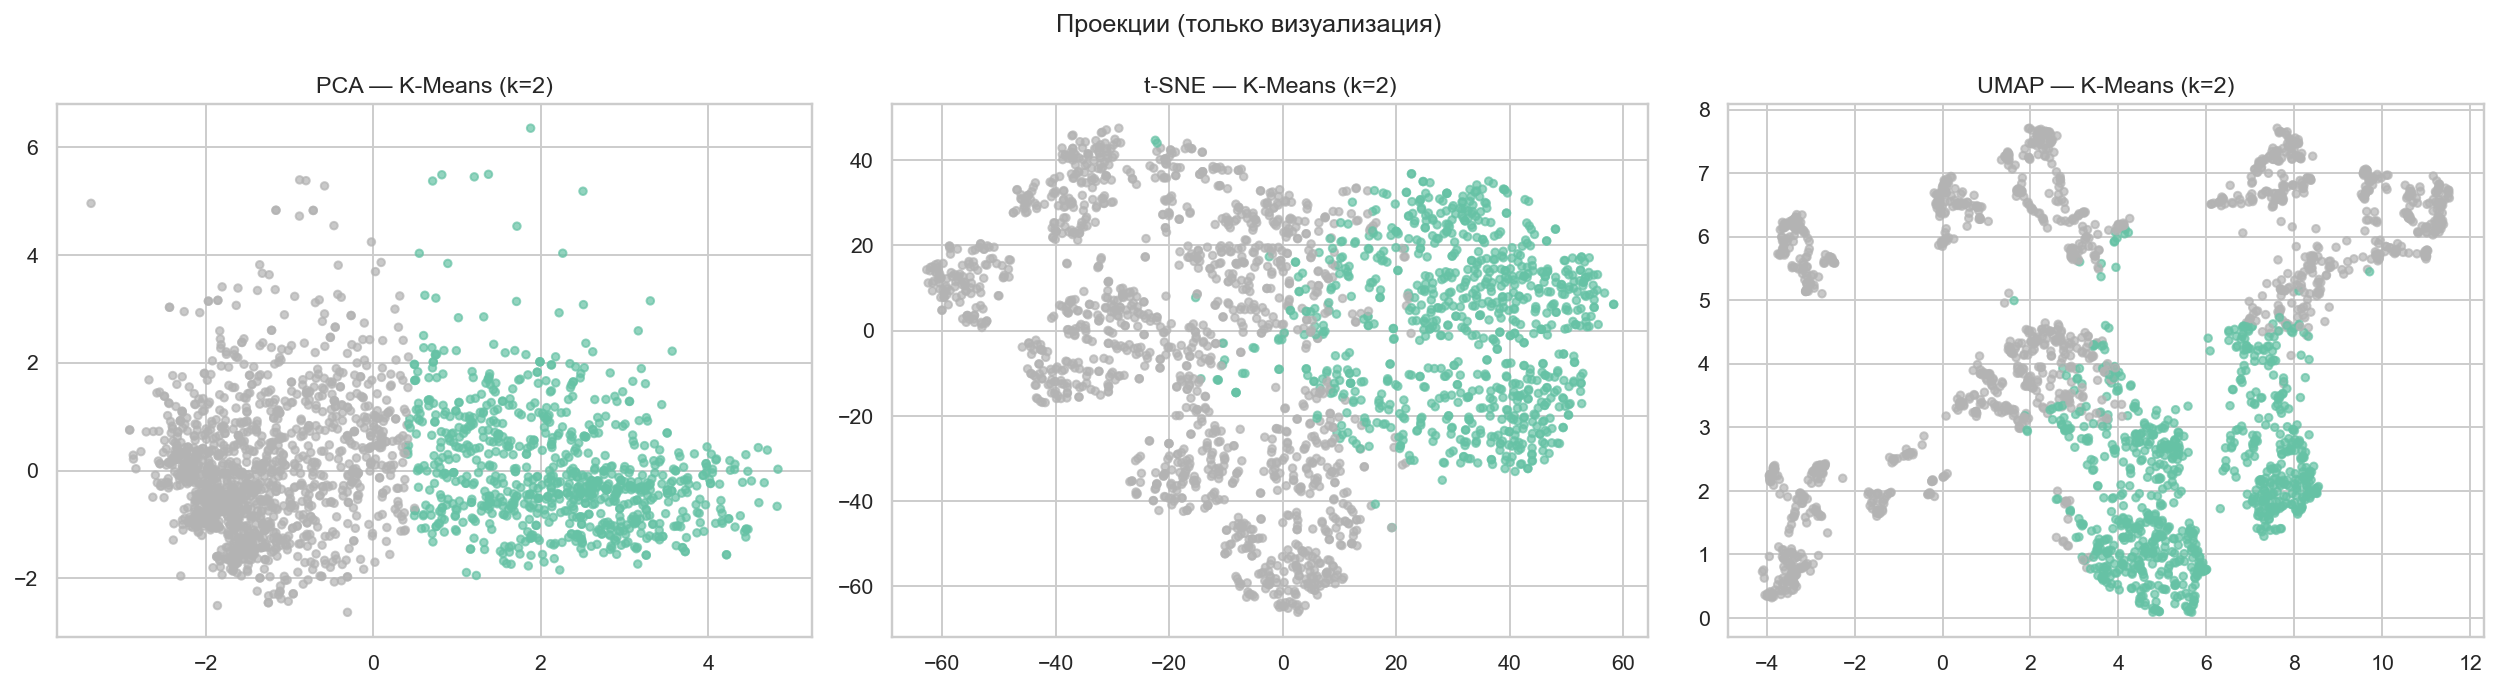

WindowsPath('C:/Users/Dezhurny/Desktop/Lesson6/output/projections_kmeans.png')

In [14]:
viz.plot_projections(prepared.x, labels, k=k_best, random_state=RANDOM_STATE)


[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\projections_3d_pca.png


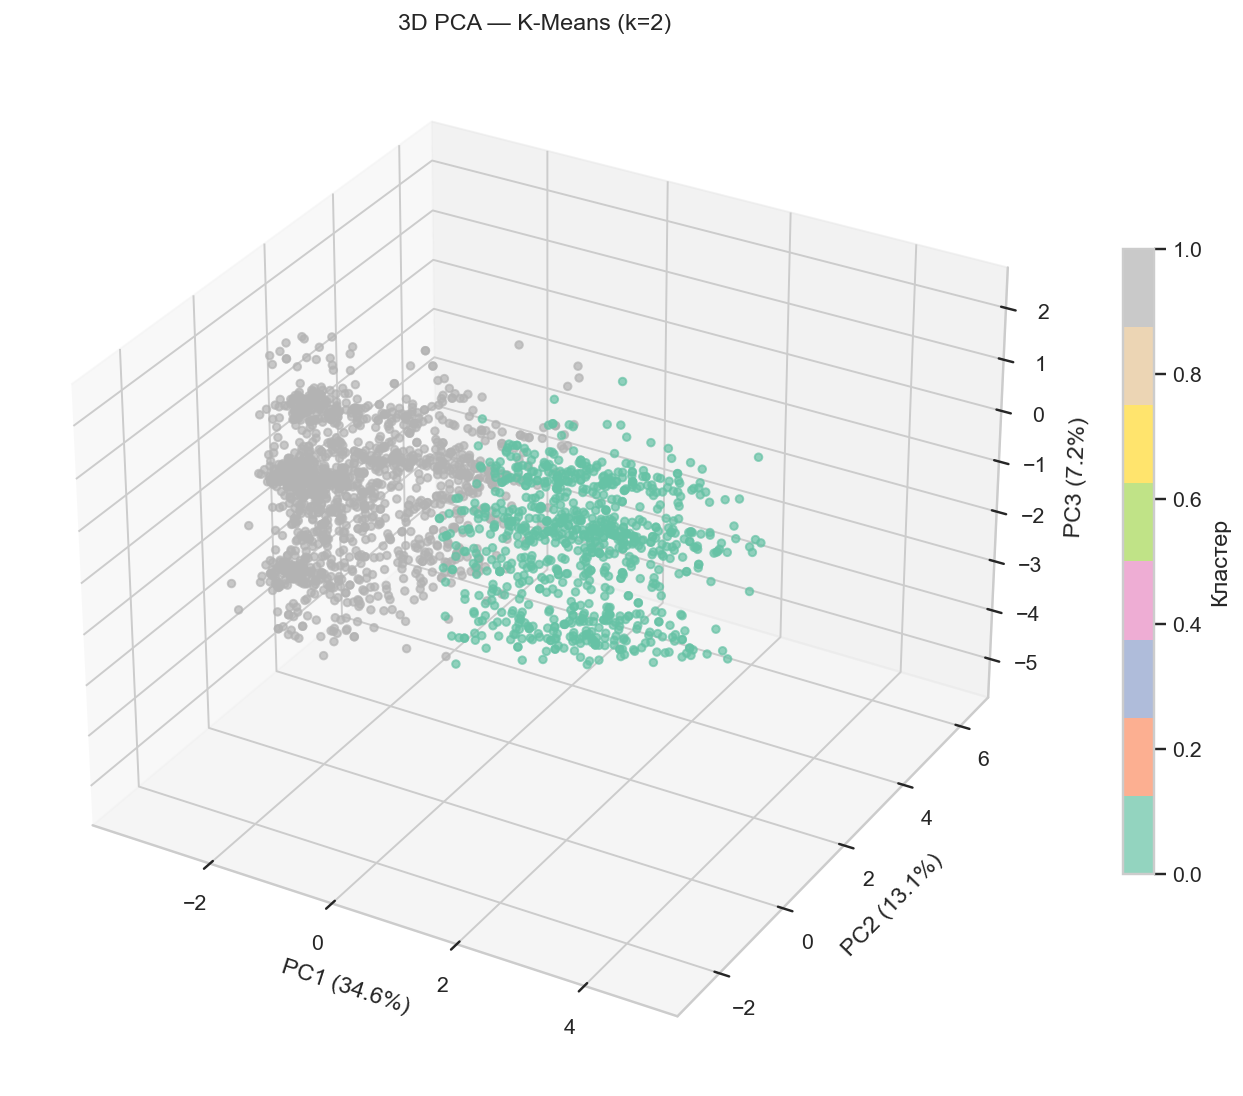

[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\projections_3d_features.png


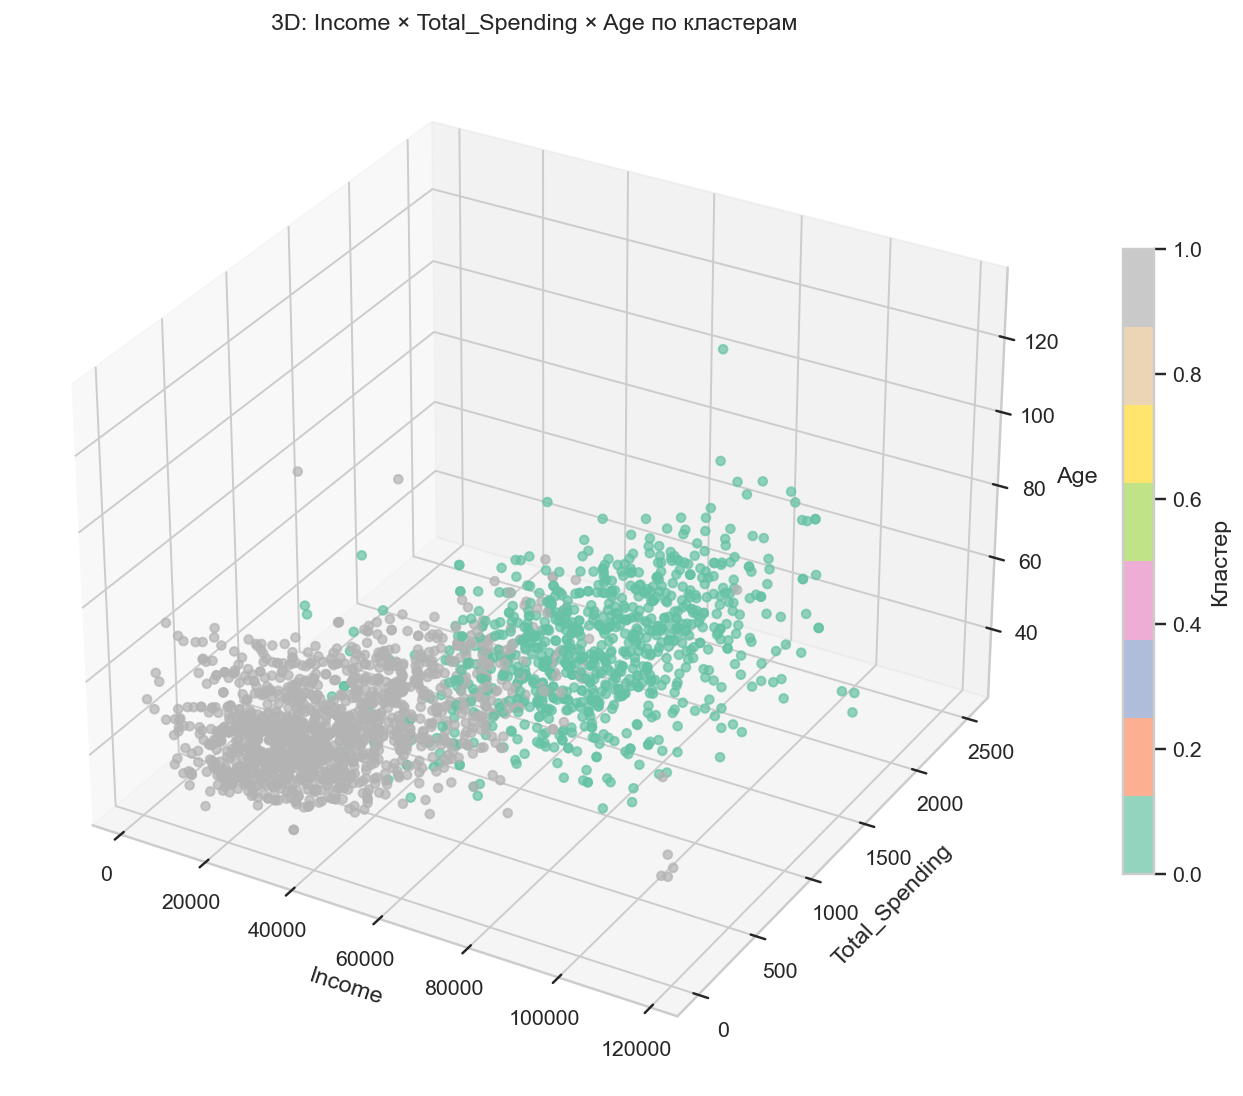

WindowsPath('C:/Users/Dezhurny/Desktop/Lesson6/output/projections_3d_features.png')

In [15]:
viz.plot_3d_pca(prepared.x, labels, k=k_best, random_state=RANDOM_STATE)
viz.plot_3d_features(prepared.processed, labels)


[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\silhouette_plot.png


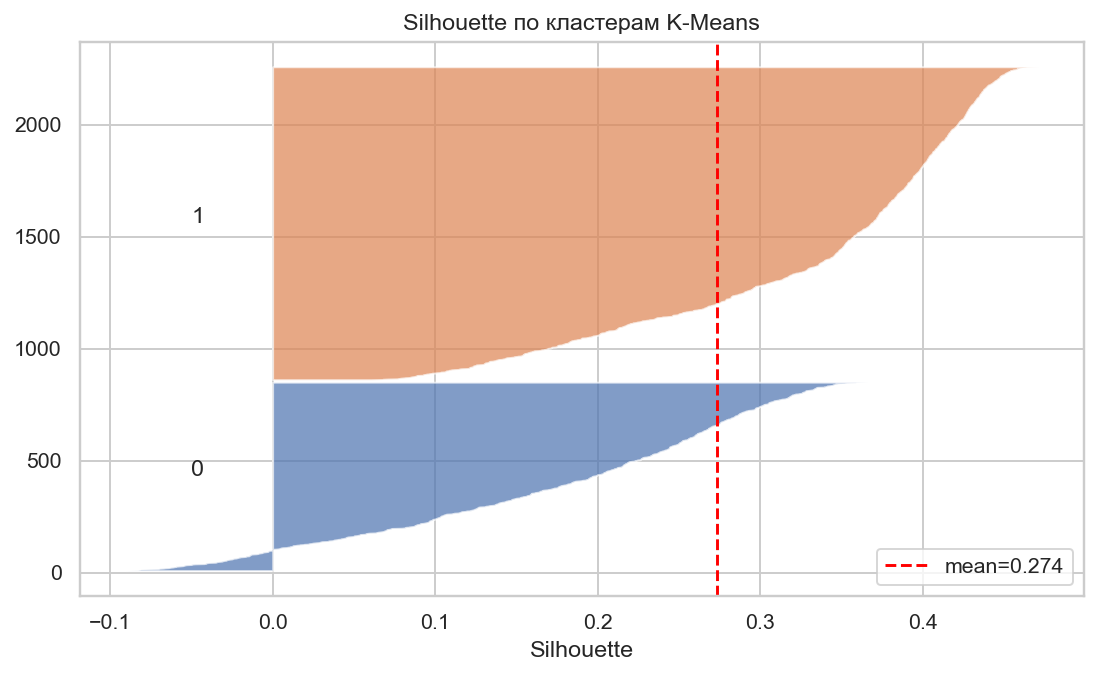

[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\cluster_radar.png


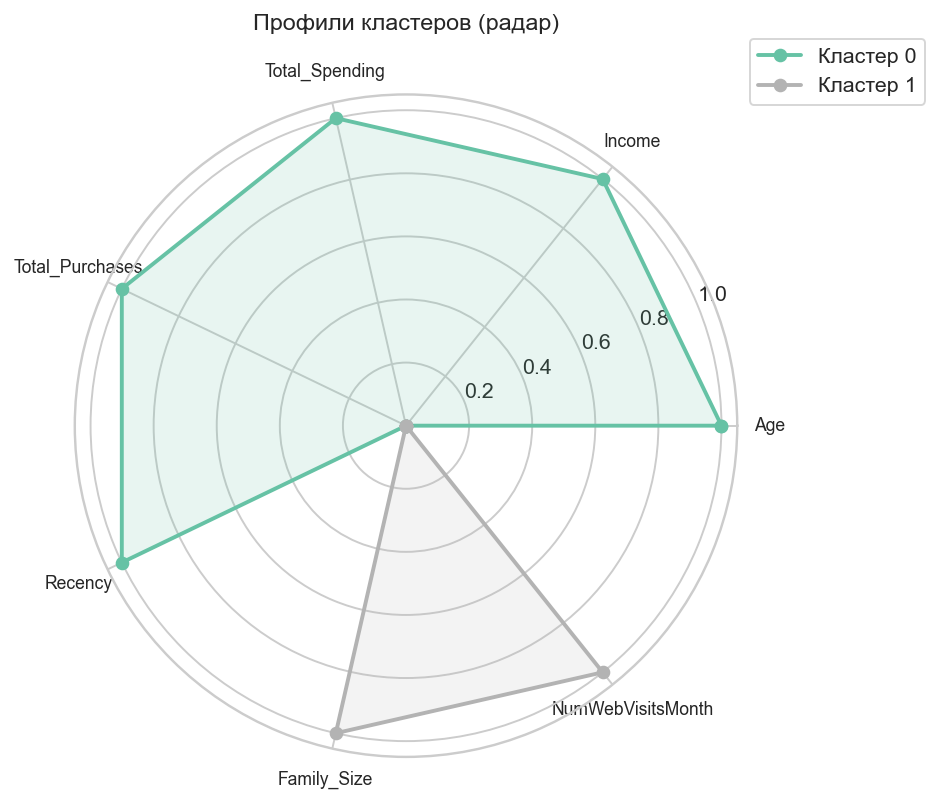

[Visualizer] Сохранено: C:\Users\Dezhurny\Desktop\Lesson6\output\cluster_parallel_coords.png


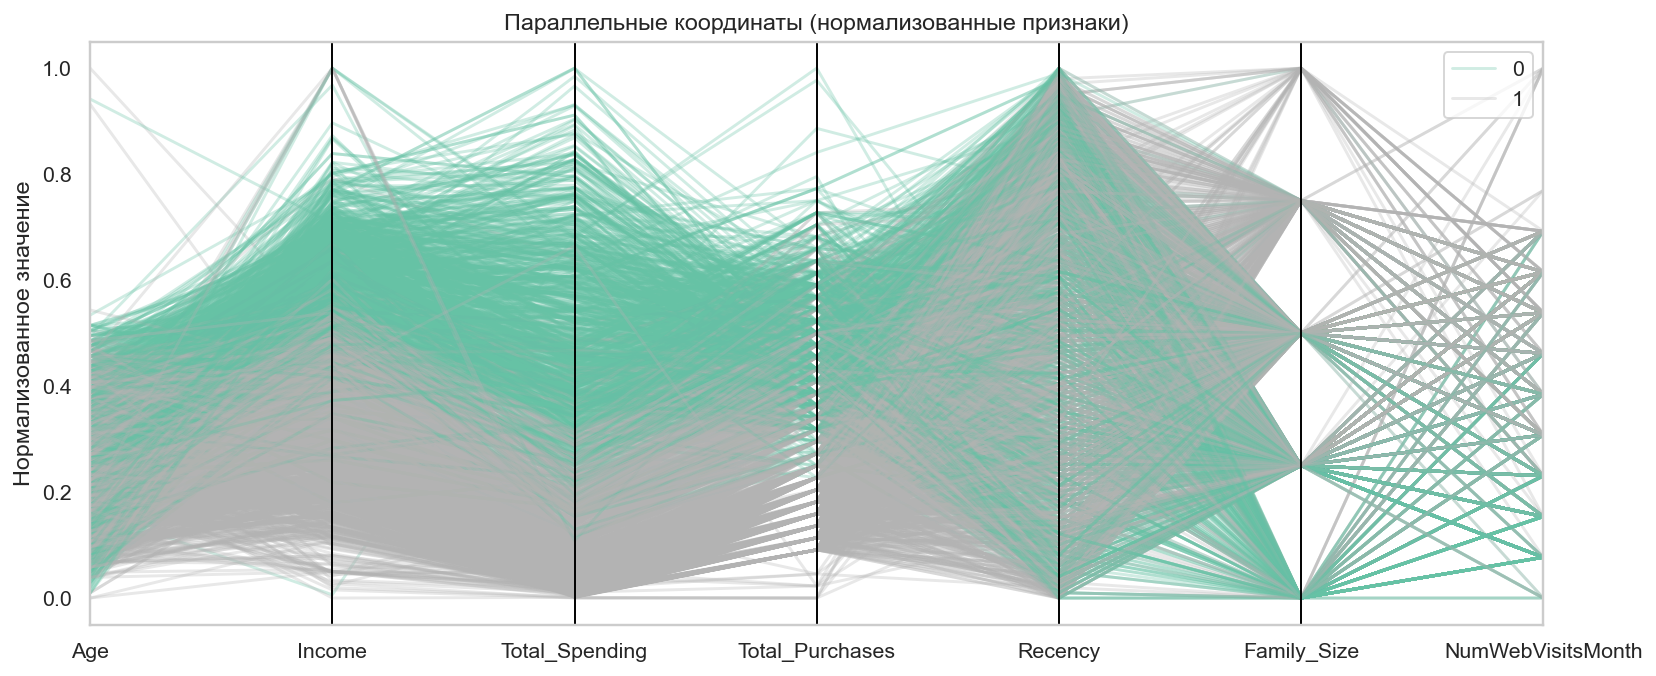

WindowsPath('C:/Users/Dezhurny/Desktop/Lesson6/output/cluster_parallel_coords.png')

In [16]:
viz.plot_silhouette(prepared.x, labels, k=k_best)
viz.plot_radar_profiles(profile, list(prepared.profile_cols))
viz.plot_parallel_coordinates(prepared.processed, labels, list(prepared.profile_cols))


## Итог

- **Выбранное k:** см. вывод `pick_k` выше
- **Гипотез подтверждено:** см. таблицу H1–H6
- **Профили кластеров:** Income, Family_Size, Total_Spending в таблице `profile`
- Все графики также сохраняются в `output/`
